## Reconstruction results on 10 12-coil MRI volumes

### 1) results with the new trajectory

### Fetching the results from wandb

In [85]:
import wandb
api = wandb.Api()

runs = api.runs("german_shama_wache/10vols_results")
# drunet results
drunet_history = runs[0].scan_history()
psnrs_drunet = [row["psnr_drunet"] for row in drunet_history]
ssims_drunet = [row["ssim_drunet"] for row in drunet_history]
# tv results
tv_history = runs[1].scan_history()
psnrs_tv = [row["psnr_tv"] for row in tv_history]
ssims_tv = [row["ssim_tv"] for row in tv_history]
# wcrr results
wcrr_history = runs[2].scan_history()
psnrs_wcrr = [row["psnr_wcrr"] for row in wcrr_history]
ssims_wcrr = [row["ssim_wcrr"] for row in wcrr_history]
# grappa results
psnrs_grappa = [row["psnr_grappa"] for row in wcrr_history]
ssims_grappa = [row["ssim_grappa"] for row in wcrr_history]
# zf results
psnrs_zf = [row["psnr_zf"] for row in wcrr_history]
ssims_zf = [row["ssim_zf"] for row in wcrr_history]

print("1) Zero-filled reconstructions")
print(f"Average PSNR: {sum(psnrs_zf)/len(psnrs_zf):.2f}, Average SSIM: {sum(ssims_zf)/len(ssims_zf):.4f}")
print("2) GRAPPA reconstructions")
print(f"Average PSNR: {sum(psnrs_grappa)/len(psnrs_grappa):.2f}, Average SSIM: {sum(ssims_grappa)/len(ssims_grappa):.4f}")
print("3) TV reconstructions")
print(f"Average PSNR: {sum(psnrs_tv)/len(psnrs_tv):.2f}, Average SSIM: {sum(ssims_tv)/len(ssims_tv):.4f}")
print("4) WCRR reconstructions")
print(f"Average PSNR: {sum(psnrs_wcrr)/len(psnrs_wcrr):.2f}, Average SSIM: {sum(ssims_wcrr)/len(ssims_wcrr):.4f}")
print("5) DRUNet reconstructions")
print(f"Average PSNR: {sum(psnrs_drunet)/len(psnrs_drunet):.2f}, Average SSIM: {sum(ssims_drunet)/len(ssims_drunet):.4f}")

1) Zero-filled reconstructions
Average PSNR: 18.07, Average SSIM: 0.4927
2) GRAPPA reconstructions
Average PSNR: 32.24, Average SSIM: 0.8898
3) TV reconstructions
Average PSNR: 34.86, Average SSIM: 0.8937
4) WCRR reconstructions
Average PSNR: 35.11, Average SSIM: 0.9127
5) DRUNet reconstructions
Average PSNR: 34.78, Average SSIM: 0.9056


### Visualise a volume

In [2]:
# choose the idx of the volume you want to display idx \in {0, 1, 2, 3, 4}
idx_vol = 4

import torch
import matplotlib.pyplot as plt

# Load the reconstructions
x_gt = torch.load(f"savings/volume_{idx_vol}_gt.pt", weights_only=True)
x_zf = torch.load(f"savings/volume_{idx_vol}_zf.pt", weights_only=True)
x_grappa = torch.load(f"savings/volume_{idx_vol}_grappa.pt", weights_only=True)
x_tv = torch.load(f"savings/volume_{idx_vol}_tv.pt", weights_only=True)
x_wcrr = torch.load(f"savings/volume_{idx_vol}_wcrr.pt", weights_only=True)
x_drunet = torch.load(f"savings/volume_{idx_vol}_drunet.pt", weights_only=True)


def plot_mid_slice(direction="z"):
    idx = [x_gt.shape[i] // 2 for i in range(-3,0)]
    
    fig, axes = plt.subplots(1, 7, figsize=(3*6,4))
    if direction=="z":
        axes[0].imshow(x_gt[...,idx[-1]].detach().cpu(), cmap='gray')
        axes[0].set_title('Reference')
        axes[1].imshow(x_zf[...,idx[-1]].detach().cpu(), cmap='gray')
        axes[1].set_title(f'Zero-filled, PSNR={psnrs_zf[idx_vol]:.2f}')
        axes[2].imshow(x_grappa[...,idx[-1]].detach().cpu(), cmap='gray')
        axes[2].set_title(f'GRAPPA, PSNR={psnrs_grappa[idx_vol]:.2f}')
        axes[3].imshow(x_tv[...,idx[-1]].detach().cpu(), cmap='gray')
        axes[3].set_title(f'TV, PSNR={psnrs_tv[idx_vol]:.2f}')
        axes[4].imshow(x_wcrr[...,idx[-1]].detach().cpu(), cmap='gray')
        axes[4].set_title(f'WCRR, PSNR={psnrs_wcrr[idx_vol]:.2f}')
        axes[5].imshow(x_drunet[...,idx[-1]].detach().cpu(), cmap='gray')
        axes[5].set_title(f'DRUNet, PSNR={psnrs_drunet[idx_vol]:.2f}')
    elif direction=="y":
        axes[0].imshow(x_gt[:,idx[-2],:].detach().cpu(), cmap='gray')
        axes[1].imshow(x_zf[:,idx[-2],:].detach().cpu(), cmap='gray')
        axes[2].imshow(x_grappa[:,idx[-2],:].detach().cpu(), cmap='gray')
        axes[3].imshow(x_tv[:,idx[-2],:].detach().cpu(), cmap='gray')
        axes[4].imshow(x_wcrr[:,idx[-2],:].detach().cpu(), cmap='gray')
        axes[5].imshow(x_drunet[:,idx[-2],:].detach().cpu(), cmap='gray')
    elif direction=="x":
        axes[0].imshow(x_gt[idx[-3],...].detach().cpu(), cmap='gray')
        axes[1].imshow(x_zf[idx[-3],...].detach().cpu(), cmap='gray')
        axes[2].imshow(x_grappa[idx[-3],...].detach().cpu(), cmap='gray')
        axes[3].imshow(x_tv[idx[-3],...].detach().cpu(), cmap='gray')
        axes[4].imshow(x_wcrr[idx[-3],...].detach().cpu(), cmap='gray')
        axes[5].imshow(x_drunet[idx[-3],...].detach().cpu(), cmap='gray')
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

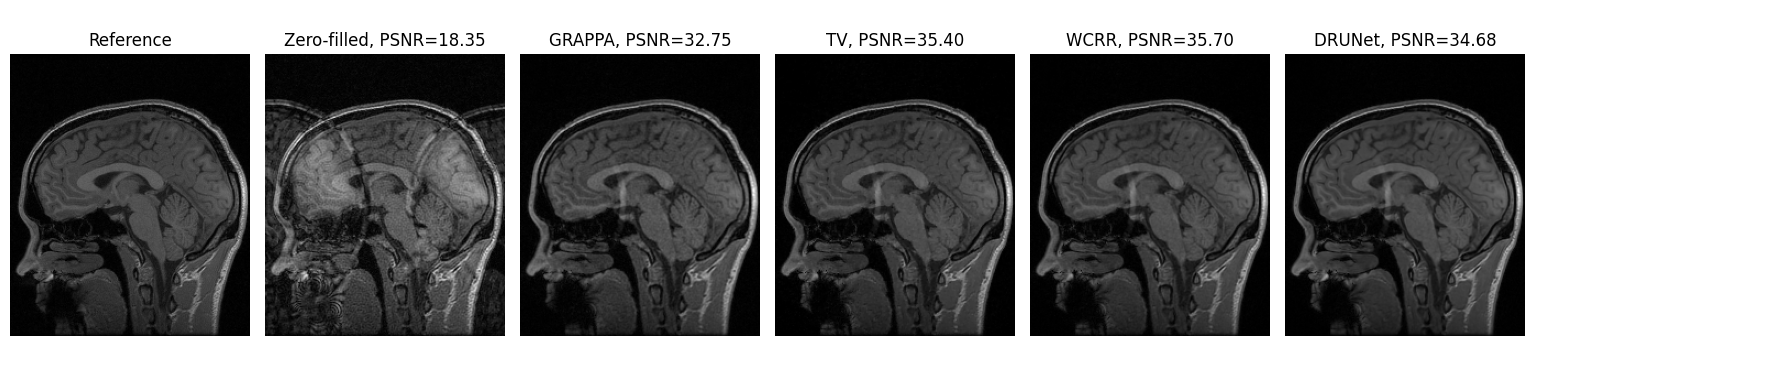

In [63]:
plot_mid_slice(direction="z")

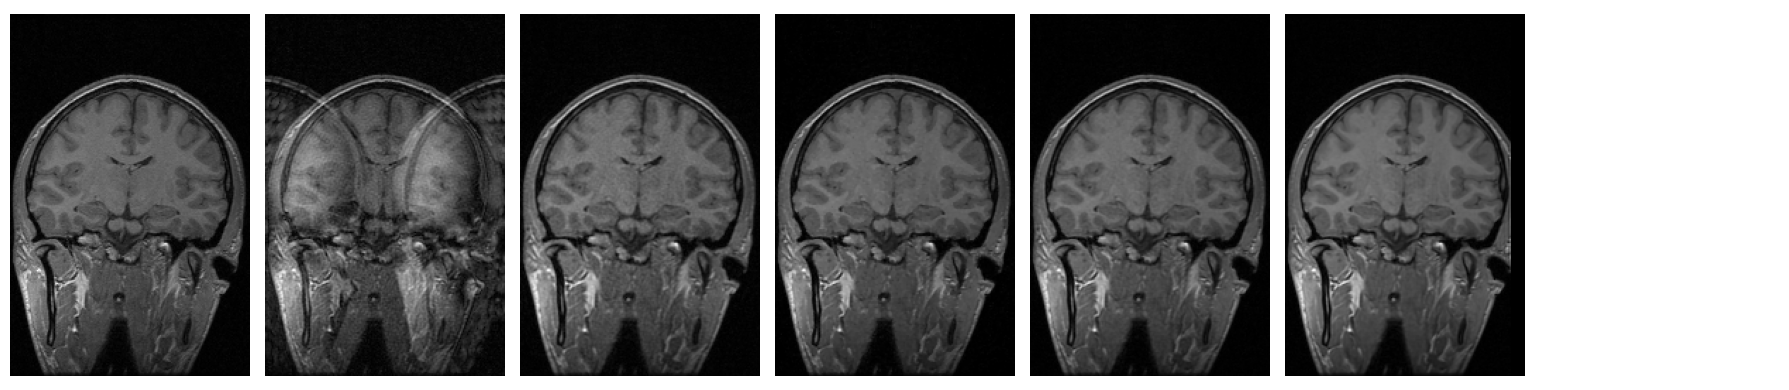

In [64]:
plot_mid_slice(direction="y")

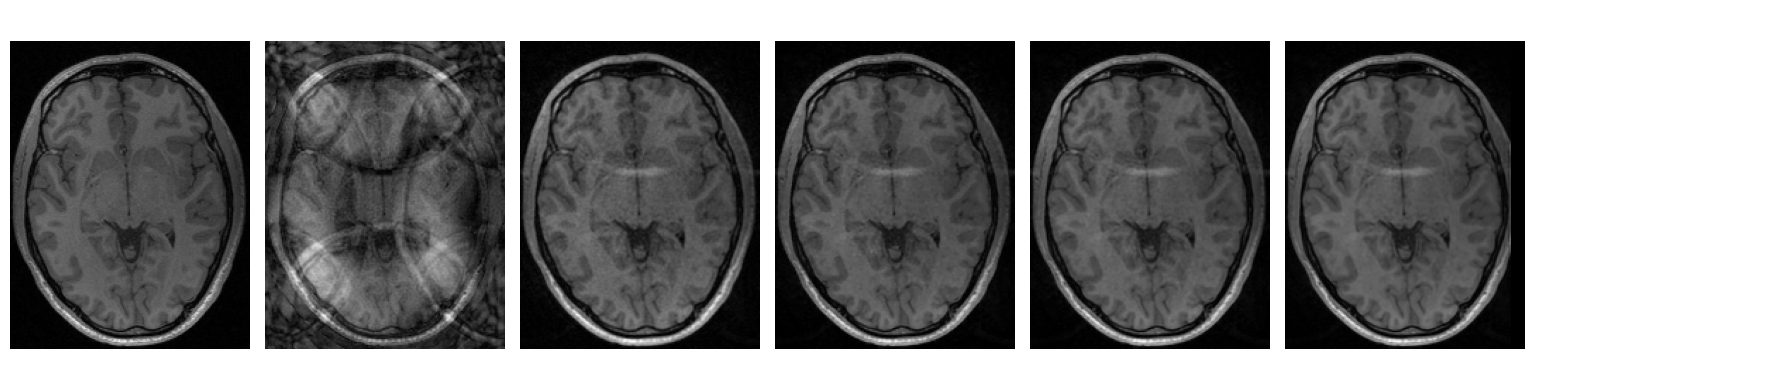

In [65]:
plot_mid_slice(direction="x")

### 2) results with the first trajectory (trajectory.bin)

### Fetching the results from wandb

In [1]:
import wandb
api = wandb.Api()

runs = api.runs("german_shama_wache/10vols_results_1st_traj")
# drunet results
drunet_history = runs[0].scan_history()
psnrs_drunet = [row["psnr_drunet"] for row in drunet_history]
ssims_drunet = [row["ssim_drunet"] for row in drunet_history]
# tv results
tv_history = runs[1].scan_history()
psnrs_tv = [row["psnr_tv"] for row in tv_history]
ssims_tv = [row["ssim_tv"] for row in tv_history]
# wcrr results
wcrr_history = runs[2].scan_history()
psnrs_wcrr = [row["psnr_wcrr"] for row in wcrr_history]
ssims_wcrr = [row["ssim_wcrr"] for row in wcrr_history]
# grappa results
psnrs_grappa = [row["psnr_grappa"] for row in wcrr_history]
ssims_grappa = [row["ssim_grappa"] for row in wcrr_history]
# zf results
psnrs_zf = [row["psnr_zf"] for row in wcrr_history]
ssims_zf = [row["ssim_zf"] for row in wcrr_history]

print("1) Zero-filled reconstructions")
print(f"Average PSNR: {sum(psnrs_zf)/len(psnrs_zf):.2f}, Average SSIM: {sum(ssims_zf)/len(ssims_zf):.4f}")
print("2) GRAPPA reconstructions")
print(f"Average PSNR: {sum(psnrs_grappa)/len(psnrs_grappa):.2f}, Average SSIM: {sum(ssims_grappa)/len(ssims_grappa):.4f}")
print("3) TV reconstructions")
print(f"Average PSNR: {sum(psnrs_tv)/len(psnrs_tv):.2f}, Average SSIM: {sum(ssims_tv)/len(ssims_tv):.4f}")
print("4) WCRR reconstructions")
print(f"Average PSNR: {sum(psnrs_wcrr)/len(psnrs_wcrr):.2f}, Average SSIM: {sum(ssims_wcrr)/len(ssims_wcrr):.4f}")
print("5) DRUNet reconstructions")
print(f"Average PSNR: {sum(psnrs_drunet)/len(psnrs_drunet):.2f}, Average SSIM: {sum(ssims_drunet)/len(ssims_drunet):.4f}")

1) Zero-filled reconstructions
Average PSNR: 26.12, Average SSIM: 0.6107
2) GRAPPA reconstructions
Average PSNR: 32.05, Average SSIM: 0.8845
3) TV reconstructions
Average PSNR: 33.21, Average SSIM: 0.8706
4) WCRR reconstructions
Average PSNR: 33.45, Average SSIM: 0.8944
5) DRUNet reconstructions
Average PSNR: 33.22, Average SSIM: 0.8879


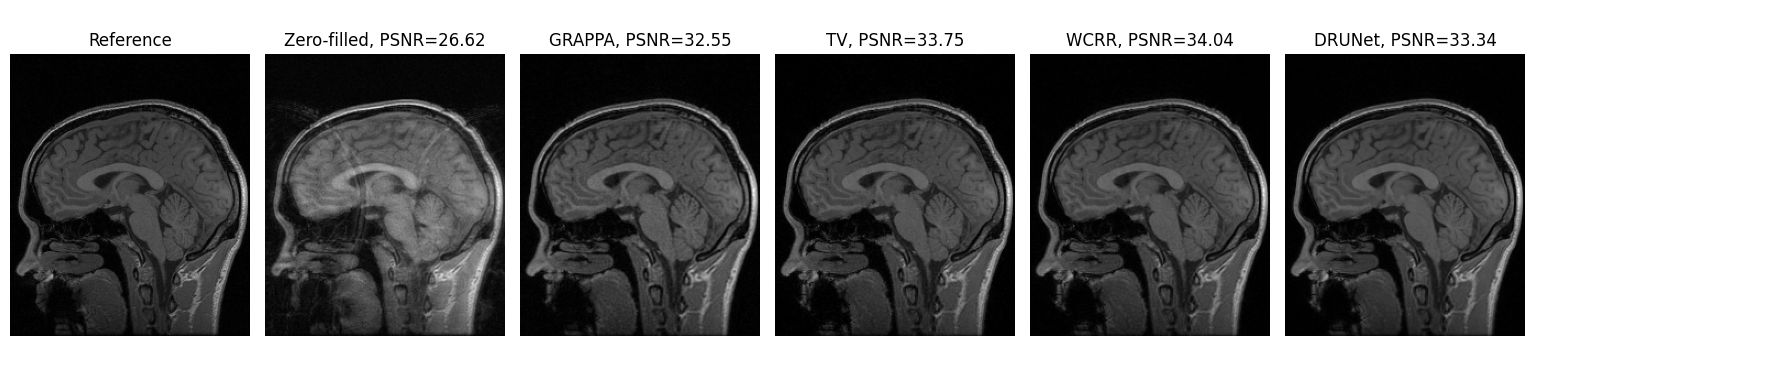

In [3]:
plot_mid_slice(direction="z")

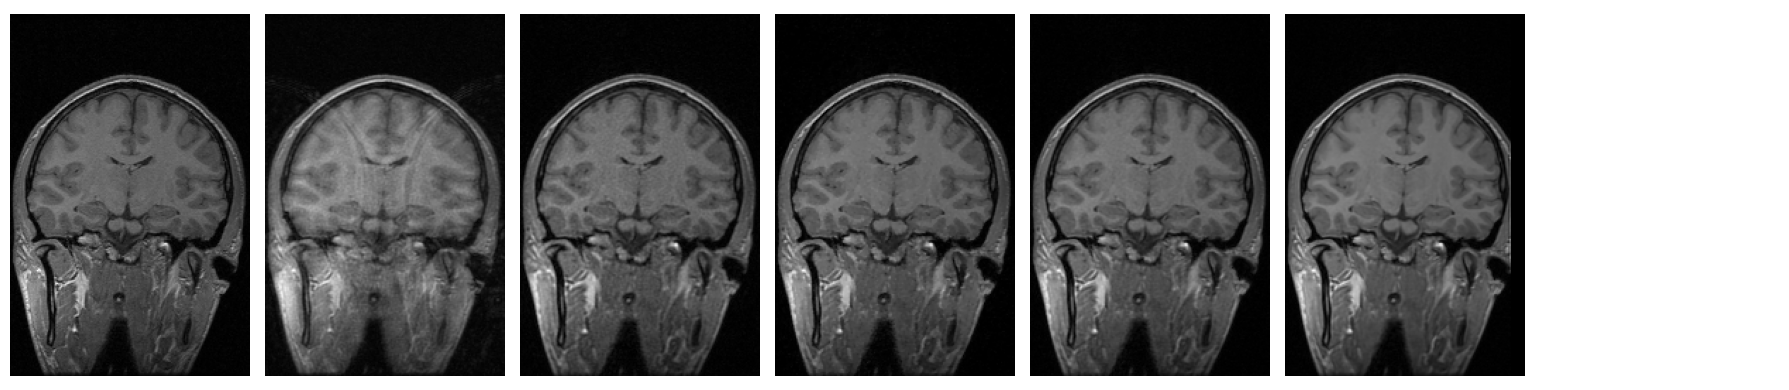

In [4]:
plot_mid_slice(direction="y")

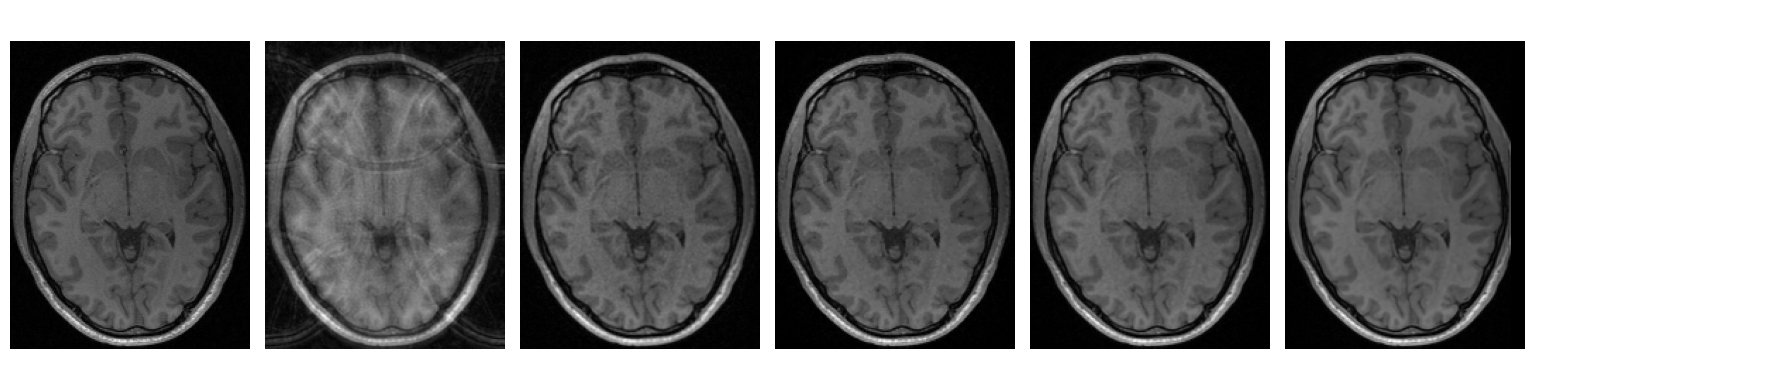

In [5]:
plot_mid_slice(direction="x")